# Stage 1 · Part 2 — 四元數與 $SO(3)$：3D 旋轉的表示 (Quaternions & $SO(3)$)

> **學習路徑定位**：`01_math_foundations` 的第二部分。Part 1 把肢段當作**平面**連桿，
> 但真實骨骼在 3D 中旋轉——肩、髖是 3 自由度的**球窩關節 (ball joint)**，動作捕捉與 IMU
> 回報的是**姿態 (orientation)**，OpenSim 每個 body 的座標系都由一個旋轉接到父座標系。
> 本部分建立描述 3D 旋轉的三種等價語言與它們之間的映射，是 Stage 2（空間代數 / $SE(3)$）、
> Stage 3（OpenSim 座標系與 ISB 慣例）、Stage 4–8 的幾何地基。

## 為什麼生物力學家需要四元數？

3D 姿態最直覺的表示是**歐拉角 (Euler angles)**——ISB 就用它定義關節角（例如肩關節的
YXY 序列）。但歐拉角有兩個致命傷：(1) **萬向鎖 (gimbal lock)**——在某些姿態下三個角
退化、失去一個自由度，速度映射變**奇異**；(2) 不利於平滑內插與數值積分。

| 表示 | 參數數 | 優點 | 缺點 |
|---|---|---|---|
| 旋轉矩陣 $R\in SO(3)$ | 9（6 個約束） | 直接作用於向量、可組合 | 冗餘、需維持正交性 |
| 歐拉角 $(\alpha,\beta,\gamma)$ | 3 | 直覺、ISB 關節角定義 | **萬向鎖**、內插/積分差 |
| 軸-角 / 旋轉向量 $\theta\hat n$ | 3 | 幾何意義最清楚（$so(3)$） | 組合不便、$\theta=\pi$ 奇異 |
| **單位四元數** $q\in S^3$ | 4（1 個約束） | **無萬向鎖**、組合便宜、易正規化、SLERP | 雙重覆蓋（$q,-q$ 同一旋轉） |

**本 notebook 會做到 Part 2 的自我評估標準**
> 用 exp map／四元數建立旋轉，三種表示互轉 **round-trip 誤差 $<10^{-9}$**；
> 用四元數積分自由剛體旋轉 12 秒，$\|q\|$ 偏離 1 $<10^{-5}$，且由 $\dot q$ 反推角速度誤差 $<10^{-2}$ rad/s。

我們會：(1) 從**反對稱生成元** $so(3)$ 與 **Rodrigues 指數映射**建立 $SO(3)$；
(2) 定義 **Hamilton 四元數**與**雙重覆蓋**；(3) 打通 quat ↔ 矩陣 ↔ 軸-角三種語言；
(4) 用 **SLERP** 說明「四元數插值 = 球面測地線 = 等角速度」；(5) 演示**萬向鎖**與它對 ISB
肩關節角的意涵；(6) 用 $\dot q=\tfrac12 q\otimes\omega$ 把角速度**積分**成姿態，並示範
**單位範數約束**如何維持——這正是 Stage 3 IMU／OpenSim 姿態管線的核心。

In [1]:
# --- 環境設定 -------------------------------------------------------------
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 讓 notebook 找得到 ../src/rotations_utils.py
SRC = pathlib.Path.cwd().parent / "src"
FIG = pathlib.Path.cwd().parent / "figures"
FIG.mkdir(exist_ok=True)
sys.path.insert(0, str(SRC))
from rotations_utils import (
    hat, vee, exp_so3, log_so3, is_rotation,
    quat_multiply, quat_conjugate, quat_inverse, quat_normalize, quat_rotate,
    quat_exp, quat_log, axis_angle_to_quat, quat_to_axis_angle,
    quat_to_matrix, matrix_to_quat, slerp,
    quat_derivative, quat_kinematics_rhs, euler_to_matrix, euler_rate_matrix,
    random_quaternion, quat_to_scipy,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.figsize": (7, 4),
                     # CJK 字型（Windows 內建 Microsoft JhengHei）讓中文標題正常顯示
                     "font.sans-serif": ["Microsoft JhengHei", "Microsoft YaHei",
                                         "SimSun", "DejaVu Sans"],
                     "axes.unicode_minus": False})
rng = np.random.default_rng(0)
print("numpy", np.__version__)

numpy 1.26.4


## 1. $SO(3)$ 與 $so(3)$：旋轉群與它的指數映射 (Rotation group & exp map)

**旋轉矩陣群**：$SO(3)=\{R\in\mathbb R^{3\times3}: R^\top R=I,\ \det R=+1\}$。
$R^\top R=I$ 保長度與角度，$\det R=+1$ 排除鏡射。它是一個 3 維的**李群 (Lie group)**。

**$so(3)$——切空間 / 李代數**：在單位元 $I$ 附近，$R(t)=\exp(t\,K)$，對 $R^\top R=I$ 微分得
$K^\top+K=0$，即 $K$ 為**反對稱矩陣**。任一反對稱矩陣可寫成 $K=[\boldsymbol\omega]_\times$
（**hat 映射**），且

$$[\boldsymbol\omega]_\times\,v = \boldsymbol\omega\times v .$$

於是 $so(3)\cong\mathbb R^3$：一個角速度向量就是一個無窮小旋轉。

**指數映射（Rodrigues 公式）** $\exp:so(3)\to SO(3)$：令 $\boldsymbol\omega=\theta\hat n$（$\theta=\|\boldsymbol\omega\|$），

$$\boxed{\;R=\exp([\boldsymbol\omega]_\times)=I+\frac{\sin\theta}{\theta}[\boldsymbol\omega]_\times+\frac{1-\cos\theta}{\theta^2}[\boldsymbol\omega]_\times^2\;}$$

它把「旋轉向量」$\theta\hat n$（繞軸 $\hat n$ 轉 $\theta$）變成旋轉矩陣。反過來的 **log map**
從 $R$ 取回 $\theta\hat n$：$\theta=\arccos\!\frac{\operatorname{tr}R-1}{2}$。

> **生物力學連結**：$[\boldsymbol\omega]_\times$ 正是剛體運動學的角速度算子——Stage 2 會看到
> $\dot R=[\boldsymbol\omega_s]_\times R$（空間座標）與 $\dot R=R[\boldsymbol\omega_b]_\times$（體座標）。
> 指數映射是**旋轉版的「等速直線運動」**：固定 $\boldsymbol\omega$ 積分出的姿態沿 $SO(3)$ 的**測地線**前進。

In [2]:
# --- so(3) hat 映射就是外積；exp_so3 產生真正的旋轉，log 為其反函數 -------------
w = np.array([0.4, -0.9, 1.3])          # 一個旋轉向量 theta*n
v = np.array([1.0, 2.0, -0.5])
print("hat(w) @ v  == w x v ? ", np.allclose(hat(w) @ v, np.cross(w, v)))
print("hat(w) 反對稱 ?          ", np.allclose(hat(w), -hat(w).T))

R = exp_so3(w)
print("\nR = exp([w]_x) =\n", np.round(R, 4))
print("\nR 是正規旋轉 (R^T R = I, det = +1) ?", is_rotation(R))
print("log(R) 取回 w ?", np.allclose(log_so3(R), w))
print("轉角 theta = ||w|| =", round(np.linalg.norm(w), 6),
      "rad =", round(np.degrees(np.linalg.norm(w)), 2), "deg")

hat(w) @ v  == w x v ?  True
hat(w) 反對稱 ?           True

R = exp([w]_x) =
 [[ 0.0036 -0.9391 -0.3436]
 [ 0.6522  0.2627 -0.7111]
 [ 0.7581 -0.2215  0.6134]]

R 是正規旋轉 (R^T R = I, det = +1) ? True
log(R) 取回 w ? True
轉角 theta = ||w|| = 1.630951 rad = 93.45 deg


## 2. 四元數與雙重覆蓋 (Quaternions & the double cover)

四元數 $q=w+xi+yj+zk$，基元滿足 **Hamilton 關係** $i^2=j^2=k^2=ijk=-1$（於是
$ij=k,\,jk=i,\,ki=j$，**不可交換**）。寫成純量-向量對 $q=(w,\mathbf v)$，乘法為

$$q_1\otimes q_2=(w_1w_2-\mathbf v_1\!\cdot\!\mathbf v_2,\ \ w_1\mathbf v_2+w_2\mathbf v_1+\mathbf v_1\times\mathbf v_2).$$

**單位四元數** $\|q\|=1$ 構成 3 維球面 $S^3$，是一個群（$\cong SU(2)$）。繞單位軸 $\hat n$
轉 $\theta$ 的旋轉對應

$$\boxed{\;q=\Big(\cos\tfrac\theta2,\ \sin\tfrac\theta2\,\hat n\Big)\;}$$

（注意是**半角** $\theta/2$）。用它旋轉向量：把 $\mathbf p$ 當純四元數 $(0,\mathbf p)$，則

$$\mathbf p'=q\otimes(0,\mathbf p)\otimes q^{*}=R(q)\,\mathbf p .$$

**雙重覆蓋 (double cover)**：因為半角，$q$ 與 $-q$ 給出**同一個** $R$——映射 $S^3\to SO(3)$
是 2 對 1，即 $SO(3)\cong S^3/\{\pm1\}$。這在數值上要小心（取「最短弧」時要挑對號），
但也帶來好處：四元數空間**沒有萬向鎖**那種座標奇異。

**組合是同態**：$R(q_1\otimes q_2)=R(q_1)R(q_2)$——四元數乘法對應旋轉合成，且只要 4 個數、
一次乘法，比 $3\times3$ 矩陣連乘便宜。

> **慣例**：本課程用**純量在前** $q=[w,x,y,z]$、**Hamilton** 乘法、**主動**旋轉。
> SciPy 的 `Rotation` 用純量在後 $[x,y,z,w]$；`rotations_utils` 提供 `quat_to_scipy` 橋接，
> 下面即用 SciPy 當**獨立第三方**交叉驗證。

In [3]:
# --- 四元數代數：雙重覆蓋、同態、與 SciPy 交叉驗證 -----------------------------
from scipy.spatial.transform import Rotation as Rot

q1 = axis_angle_to_quat([0, 0, 1], np.radians(90))    # 繞 z 轉 90 deg
q2 = axis_angle_to_quat([1, 0, 0], np.radians(45))    # 繞 x 轉 45 deg

# (1) 雙重覆蓋：q 與 -q 同一旋轉
print("R(q1) == R(-q1) ?", np.allclose(quat_to_matrix(q1), quat_to_matrix(-q1)))

# (2) 組合同態：R(q1 x q2) == R(q1) R(q2)
lhs = quat_to_matrix(quat_multiply(q1, q2))
rhs = quat_to_matrix(q1) @ quat_to_matrix(q2)
print("R(q1 x q2) == R(q1) R(q2) ?", np.allclose(lhs, rhs))

# (3) 旋轉向量：q (0,p) q* == R(q) p
p = np.array([1.0, 2.0, 3.0])
print("quat_rotate 與矩陣作用一致 ?",
      np.allclose(quat_rotate(q1, p), quat_to_matrix(q1) @ p))

# (4) 與 SciPy（純量在後）交叉驗證
R_ours  = quat_to_matrix(q1)
R_scipy = Rot.from_quat(quat_to_scipy(q1)).as_matrix()
print("與 SciPy 一致 ?", np.allclose(R_ours, R_scipy), " 最大差 =",
      f"{np.abs(R_ours - R_scipy).max():.1e}")

R(q1) == R(-q1) ? True
R(q1 x q2) == R(q1) R(q2) ? True
quat_rotate 與矩陣作用一致 ? True
與 SciPy 一致 ? True  最大差 = 2.2e-16


## 3. 三種語言的等價與互轉 (Equivalence & conversions)

旋轉矩陣、單位四元數、旋轉向量（軸-角）描述**同一件事**，可無損互換：

$$\theta\hat n\ \xrightarrow{\ \exp\ }\ R,\qquad
R\ \xrightarrow{\ \log\ }\ \theta\hat n,\qquad
q=\big(\cos\tfrac\theta2,\sin\tfrac\theta2\hat n\big)\ \xrightarrow{\ R(q)\ }\ R .$$

`rotations_utils` 對應：`exp_so3`/`log_so3`（$so(3)\!\leftrightarrow\!SO(3)$）、
`quat_exp`/`quat_log`（$so(3)\!\leftrightarrow\!S^3$）、`quat_to_matrix`/`matrix_to_quat`
（$S^3\!\leftrightarrow\!SO(3)$，後者用 **Shepperd** 數值穩定法，先解最大分量再回推其餘）。

**驗證優先（呼應 Part 1 的能量守恆精神）**：這些互轉必須**round-trip 還原**且彼此一致。
下面對 2000 組隨機旋轉量測最大誤差——這是與任何科學結論無關的正確性指標。

In [4]:
# --- 三語互轉的 round-trip 與一致性（2000 組隨機旋轉的最大誤差）----------------
N = 2000
e_explog, e_qmat, e_matq, e_qexp = 0.0, 0.0, 0.0, 0.0
for _ in range(N):
    q = random_quaternion(rng)
    R = quat_to_matrix(q)
    w = log_so3(R)
    e_explog = max(e_explog, np.linalg.norm(exp_so3(w) - R))          # R -> log -> exp
    e_matq   = max(e_matq,   np.linalg.norm(quat_to_matrix(matrix_to_quat(R)) - R))
    e_qmat   = max(e_qmat,   np.linalg.norm(matrix_to_quat(quat_to_matrix(q)) - q))
    e_qexp   = max(e_qexp,   np.linalg.norm(quat_to_matrix(quat_exp(w)) - R))  # 四元數 vs 矩陣指數

print(f"R  -> log -> exp   還原誤差        : {e_explog:.2e}")
print(f"R  -> quat -> R    還原誤差        : {e_matq:.2e}")
print(f"q  -> R -> quat    還原誤差        : {e_qmat:.2e}")
print(f"quat_exp 與 exp_so3 一致 (經 R)    : {e_qexp:.2e}")
print("\n=> 三種表示互為無損轉換，round-trip 誤差達機器精度等級 (< 1e-9)。")

R  -> log -> exp   還原誤差        : 8.72e-11
R  -> quat -> R    還原誤差        : 2.00e-15
q  -> R -> quat    還原誤差        : 7.47e-16
quat_exp 與 exp_so3 一致 (經 R)    : 8.72e-11

=> 三種表示互為無損轉換，round-trip 誤差達機器精度等級 (< 1e-9)。


## 4. SLERP：球面測地線與等角速度插值 (Spherical linear interpolation)

要在兩個姿態 $q_0,q_1$ 之間**平滑內插**（動作捕捉補幀、關鍵影格動畫、姿態濾波），
直接對四元數做線性內插 (LERP) 再正規化會**角速度忽快忽慢**。正確做法是沿 $S^3$ 的
**大圓測地線**走——**SLERP**：

$$\mathrm{slerp}(q_0,q_1;t)=\frac{\sin\!\big((1-t)\Omega\big)}{\sin\Omega}\,q_0+\frac{\sin(t\Omega)}{\sin\Omega}\,q_1,\qquad\cos\Omega=q_0\!\cdot\!q_1 .$$

它的關鍵性質是**等角速度**：投影到 $SO(3)$ 後，姿態以**固定角速率**從 $q_0$ 轉到 $q_1$。
下圖左：SLERP 的轉角隨 $t$ **線性**成長（LERP 則彎曲）；右：SLERP 的瞬時角速率是**常數**，
LERP 在中段明顯鼓起。這就是為什麼 SLERP 是內插姿態的標準做法。

SLERP 角速率標準差 = 1.71e-12 deg  (≈0 → 等角速度)
LERP  角速率標準差 = 20.54 deg  (明顯變化)


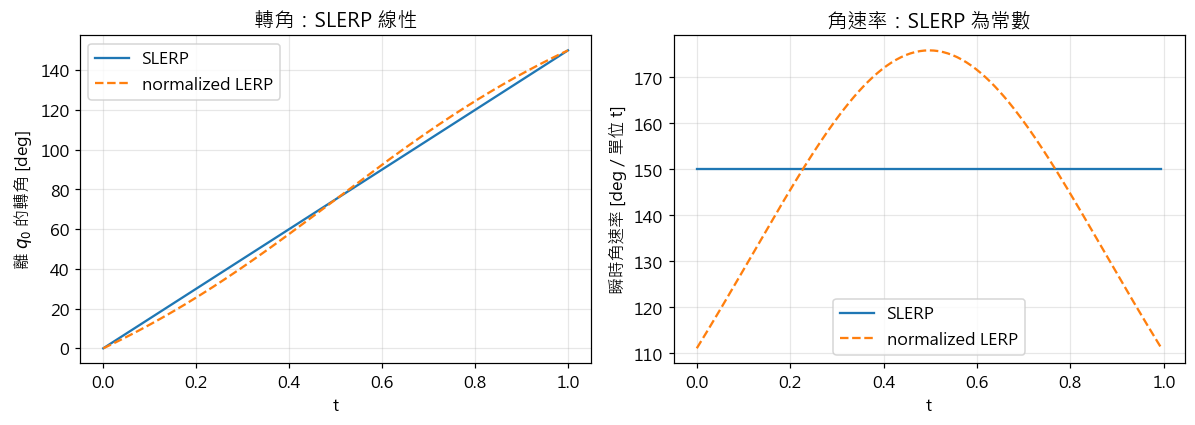

In [5]:
# --- Fig 07: SLERP vs 正規化 LERP（等角速度 vs 忽快忽慢）------------------------
def rel_angle(qa, qb):
    return quat_to_axis_angle(quat_multiply(quat_conjugate(qa), qb))[1]

q0 = np.array([1.0, 0.0, 0.0, 0.0])
q1 = axis_angle_to_quat([0.3, 0.6, 0.7], np.radians(150))
ts = np.linspace(0, 1, 200)
qs_slerp = slerp(q0, q1, ts)
qs_lerp  = (1 - ts)[:, None] * q0 + ts[:, None] * q1
qs_lerp /= np.linalg.norm(qs_lerp, axis=1, keepdims=True)

ang_s = np.array([rel_angle(q0, q) for q in qs_slerp])
ang_l = np.array([rel_angle(q0, q) for q in qs_lerp])
spd = lambda qs: np.array([rel_angle(qs[i], qs[i+1]) for i in range(len(qs)-1)]) / (ts[1]-ts[0])
sp_s, sp_l = spd(qs_slerp), spd(qs_lerp)
print(f"SLERP 角速率標準差 = {np.degrees(sp_s).std():.2e} deg  (≈0 → 等角速度)")
print(f"LERP  角速率標準差 = {np.degrees(sp_l).std():.2f} deg  (明顯變化)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ts, np.degrees(ang_s), label="SLERP")
ax[0].plot(ts, np.degrees(ang_l), "--", label="normalized LERP")
ax[0].set(xlabel="t", ylabel="離 $q_0$ 的轉角 [deg]", title="轉角：SLERP 線性")
ax[0].legend()
ax[1].plot(ts[:-1], np.degrees(sp_s), label="SLERP")
ax[1].plot(ts[:-1], np.degrees(sp_l), "--", label="normalized LERP")
ax[1].set(xlabel="t", ylabel="瞬時角速率 [deg / 單位 t]", title="角速率：SLERP 為常數")
ax[1].legend()
fig.tight_layout(); fig.savefig(FIG / "07_slerp_vs_lerp.png"); plt.show()

## 5. 萬向鎖：歐拉角為何是壞的姿態座標 (Gimbal lock)

ISB / OpenSim 用**歐拉角序列**定義關節角（例如肩關節 **YXY**：抬臂平面、抬臂角、軸向轉）。
歐拉角把姿態拆成繞三個軸的連續旋轉 $R=R_{a_1}(\alpha)R_{a_2}(\beta)R_{a_3}(\gamma)$。
問題在**歐拉角速率 → 角速度**的映射 $\boldsymbol\omega=E(\alpha,\beta,\gamma)\,\dot{(\cdot)}$：

$$\boldsymbol\omega_s=\dot\alpha\,a_1+\dot\beta\,(R_{a_1}a_2)+\dot\gamma\,(R_{a_1}R_{a_2}a_3),$$

$E$ 的三個行是三次旋轉軸「當下在世界座標中的方向」。當**首軸與末軸對齊**時它們共面，
$E$ **奇異**（$\det E\to0$），一個自由度瞬間消失——這就是**萬向鎖**。對 ZYX 卡登角，
$|\det E|=\cos\beta$，在中間角 $\beta=\pm90°$ 歸零（下圖）。對肩關節 YXY，奇異發生在
**抬臂角 = 0**（手臂自然下垂）——ISB 之所以警告肩關節序列要小心，正是這個原因。

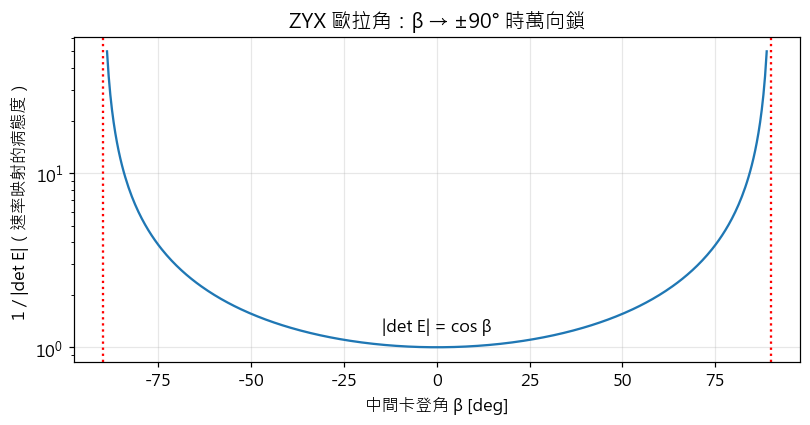

|det E(β=0.37)| = 0.93233 vs cos β = 0.93233

ISB 肩關節 YXY（抬臂平面, 抬臂角, 軸向轉）——中間角=抬臂角:
  抬臂角 =   1.7 deg  ->  |det E| = 0.0300   <-- 接近萬向鎖
  抬臂角 =  17.2 deg  ->  |det E| = 0.2955
  抬臂角 =  57.3 deg  ->  |det E| = 0.8415


In [6]:
# --- Fig 08: ZYX 卡登角的萬向鎖（速率映射行列式在 beta=±90° 爆掉）--------------
betas = np.linspace(-np.pi/2 + 0.02, np.pi/2 - 0.02, 400)
inv_det = [1.0 / abs(np.linalg.det(euler_rate_matrix([0.4, b, 0.7], "zyx"))) for b in betas]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(np.degrees(betas), inv_det)
ax.axvline(-90, color="r", ls=":"); ax.axvline(90, color="r", ls=":")
ax.set(xlabel="中間卡登角 β [deg]", ylabel="1 / |det E|（速率映射的病態度）",
       yscale="log", title="ZYX 歐拉角：β → ±90° 時萬向鎖")
ax.text(0, ax.get_ylim()[0]*1.5, "|det E| = cos β", ha="center")
fig.tight_layout(); fig.savefig(FIG / "08_gimbal_lock.png"); plt.show()

# 確認閉式 |det E| = cos β
b = 0.37
print(f"|det E(β=0.37)| = {abs(np.linalg.det(euler_rate_matrix([0.4, b, 0.7],'zyx'))):.5f}",
      f"vs cos β = {np.cos(b):.5f}")

# ISB 肩關節 YXY：抬臂角(中間角)趨近 0（手臂下垂）時映射奇異
print("\nISB 肩關節 YXY（抬臂平面, 抬臂角, 軸向轉）——中間角=抬臂角:")
for elev in [0.03, 0.3, 1.0]:
    E = euler_rate_matrix([0.5, elev, 0.4], "yxy")
    print(f"  抬臂角 = {np.degrees(elev):5.1f} deg  ->  |det E| = {abs(np.linalg.det(E)):.4f}"
          + ("   <-- 接近萬向鎖" if elev < 0.1 else ""))

## 6. 姿態運動學與指數映射的測地線 (Orientation kinematics)

角速度如何改變姿態？四元數運動學是一條**線性** ODE：

$$\boxed{\;\dot q=\tfrac12\,q\otimes(0,\boldsymbol\omega_b)\quad(\text{體座標}),\qquad
\dot q=\tfrac12\,(0,\boldsymbol\omega_s)\otimes q\quad(\text{空間座標})\;}$$

分別對應矩陣形式 $\dot R=R[\boldsymbol\omega_b]_\times$ 與 $\dot R=[\boldsymbol\omega_s]_\times R$。
若體座標角速度 $\boldsymbol\omega_b$ **固定**，解為 $R(t)=R_0\exp(t[\boldsymbol\omega_b]_\times)$——
姿態沿 $SO(3)$ 的**測地線**等速前進，物體上一點的軌跡在單位球上畫出一個**圓**（下圖）。

固定角速度積分 == exp_so3(omega·T) ? True


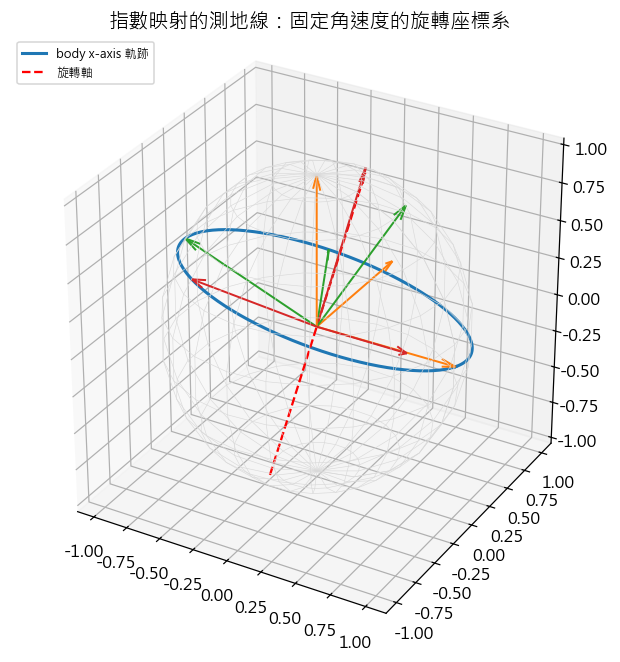

In [7]:
# --- Fig 09: 固定角速度 → 沿測地線旋轉的體座標系與軌跡 --------------------------
axis = np.array([0.2, 0.3, 1.0]); axis /= np.linalg.norm(axis)
omega = 2 * np.pi * axis                       # t in [0,1] 剛好轉一整圈
tt = np.linspace(0, 1, 200)
e1 = np.array([1.0, 0.0, 0.0])
path = np.array([exp_so3(omega * t) @ e1 for t in tt])   # 體座標 x 軸尖端的軌跡

# 驗證：固定體座標角速度，四元數積分結果 == 矩陣指數
qT = quat_exp(omega * 1.0)
print("固定角速度積分 == exp_so3(omega·T) ?",
      np.allclose(quat_to_matrix(qT), exp_so3(omega * 1.0)))

fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection="3d")
u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:12j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), color="0.85", lw=0.4)
ax.plot(path[:, 0], path[:, 1], path[:, 2], color="C0", lw=2, label="body x-axis 軌跡")
ax.plot([-axis[0], axis[0]], [-axis[1], axis[1]], [-axis[2], axis[2]], "r--", label="旋轉軸")
for t, c in zip([0.0, 0.33, 0.66], ["C1", "C2", "C3"]):
    R = exp_so3(omega * t)
    for k in range(3):
        ax.quiver(0, 0, 0, R[0, k], R[1, k], R[2, k], color=c, lw=1.3, arrow_length_ratio=0.1)
ax.set_box_aspect((1, 1, 1)); ax.set_title("指數映射的測地線：固定角速度的旋轉座標系")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "09_exp_map_geodesic.png"); plt.show()

## 7. 由角速度積分姿態：單位範數約束與 IMU 管線 (Integrating $\omega$ into orientation)

實務上（IMU 陀螺儀、預測模擬）我們有隨時間變化的 $\boldsymbol\omega_b(t)$，要積分出姿態
$q(t)$。這裡有一個 Part 1「積分器結構比階數更根本」的姿態版本：$q$ **必須待在單位球
$S^3$ 上**，但一般 ODE 步進會把它推離球面。下圖左：固定步長 forward-Euler 若**不重正規化**，
$\|q\|$ 會**系統性漂離 1**（此處 12 秒漂到約 1.05）；每步除以 $\|q\|$（或加 Baumgarte 拉回項，
見 `quat_kinematics_rhs`）就能把它釘在球面上。這是 Stage 3 姿態估計、Stage 8 姿態變數
的必備技巧。

右圖：反過來，由積出的 $q(t)$ 用 $\boldsymbol\omega_b=\log\!\big(q_i^{-1}q_{i+1}\big)/\Delta t$
**反推**角速度，與輸入的 $\boldsymbol\omega_b(t)$ 吻合——驗證 $\dot q=\tfrac12 q\otimes\omega$ 正確
（這正是逆運算：由姿態序列回推角速度，Stage 3 由動作捕捉算關節角速度的原型）。

不重正規化 12 s 後 ||q|| = 1.0468（漂離 1）
重正規化   12 s 後 ||q|| = 1.0000（守住約束）


由 q(t) 反推角速度的最大誤差 = 4.82e-03 rad/s（O(Δt)）


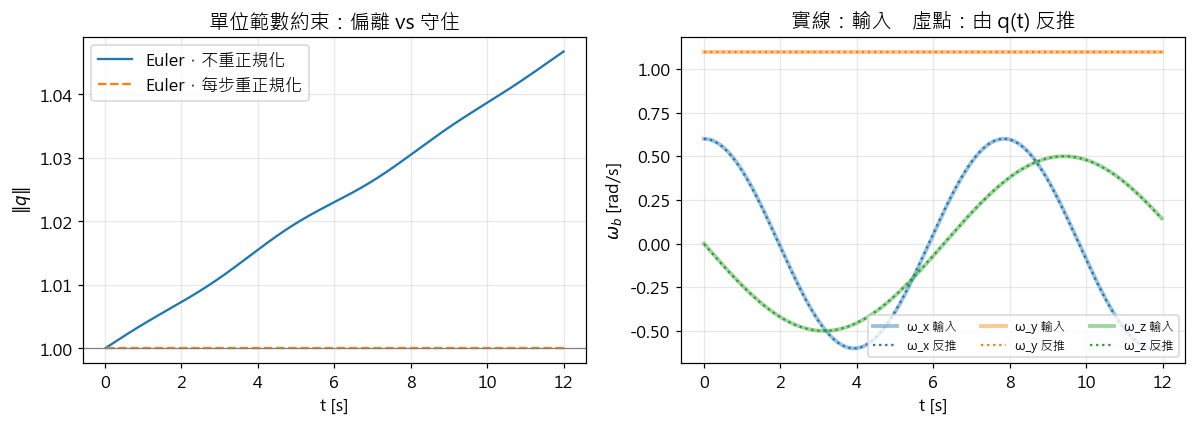

In [8]:
# --- Fig 10: 積分 dq/dt = 1/2 q x omega_b ；範數約束 + 角速度反推 --------------
def omega_fn(t):
    return np.array([0.6*np.cos(0.8*t), 1.1, -0.5*np.sin(0.5*t)])   # 隨時間變化的體角速度

q0, T, dt = np.array([1.0, 0, 0, 0.0]), 12.0, 0.02

# (A) 固定步長 Euler：不重正規化 vs 重正規化 -> ||q|| 是否守約束
def euler_integrate(renorm):
    q = q0.copy(); norms = []
    for i in range(int(T/dt)):
        q = q + dt * quat_derivative(q, omega_fn(i*dt), "body")
        if renorm:
            q /= np.linalg.norm(q)
        norms.append(np.linalg.norm(q))
    return np.array(norms)
tn = dt * (1 + np.arange(int(T/dt)))
norm_naive, norm_renorm = euler_integrate(False), euler_integrate(True)
print(f"不重正規化 12 s 後 ||q|| = {norm_naive[-1]:.4f}（漂離 1）")
print(f"重正規化   12 s 後 ||q|| = {norm_renorm[-1]:.4f}（守住約束）")

# (B) 精確積分後由 q(t) 反推 omega_b，與輸入比對
sol = solve_ivp(quat_kinematics_rhs(omega_fn, "body"), (0, T), q0,
                rtol=1e-10, atol=1e-12, dense_output=True, max_step=0.02)
tg = np.linspace(0, T, 600); Q = sol.sol(tg); Q /= np.linalg.norm(Q, axis=0)
rec = np.array([quat_log(quat_multiply(quat_conjugate(Q[:, i]), Q[:, i+1])) / (tg[1]-tg[0])
                for i in range(len(tg)-1)])
true = np.array([omega_fn(t) for t in tg[:-1]])
print(f"由 q(t) 反推角速度的最大誤差 = {np.abs(rec-true).max():.2e} rad/s（O(Δt)）")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(tn, norm_naive, label="Euler，不重正規化")
ax[0].plot(tn, norm_renorm, "--", label="Euler，每步重正規化")
ax[0].axhline(1.0, color="0.5", lw=0.8)
ax[0].set(xlabel="t [s]", ylabel="$\\|q\\|$", title="單位範數約束：偏離 vs 守住")
ax[0].legend()
for k, c, lab in zip(range(3), ["C0", "C1", "C2"], ["ω_x", "ω_y", "ω_z"]):
    ax[1].plot(tg[:-1], true[:, k], c, lw=2.5, alpha=0.45, label=f"{lab} 輸入")
    ax[1].plot(tg[:-1], rec[:, k], c, ls=":", lw=1.5, label=f"{lab} 反推")
ax[1].set(xlabel="t [s]", ylabel="$\\omega_b$ [rad/s]", title="實線：輸入　虛點：由 q(t) 反推")
ax[1].legend(ncol=3, fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "10_quaternion_integration.png"); plt.show()

## 8. 生物力學連結與前瞻 (Biomechanics & what's next)

- **球窩關節**：肩（盂肱）、髖是 3 自由度旋轉關節。它們的姿態最好以四元數／$SO(3)$ 表示，
  ISB 的歐拉角僅為**報告用座標**——分析與內插請回到四元數，避開萬向鎖（§5 的肩關節 YXY 例）。
- **IMU 慣性感測**：穿戴式陀螺儀輸出 $\boldsymbol\omega_b(t)$，姿態估計（互補濾波、Madgwick、
  Kalman）核心就是 §7 的 $\dot q=\tfrac12 q\otimes\omega$ 加單位範數約束。
- **動作捕捉與姿態平滑**：關鍵影格之間用 SLERP（§4）維持等角速度；旋轉平均、濾波都在 $S^3$ 上做。
- **$\to$ Stage 2（$SE(3)$ 與空間代數）**：把旋轉 $SO(3)$ 加上平移得剛體位姿群 $SE(3)$，
  角速度＋線速度合成 6 維**旋量 (twist)** $\xi\in se(3)$；本章的 hat／exp／log 直接推廣，
  是 RNEA／CRBA／ABA 的幾何語言（Featherstone；Lynch & Park）。
- **$\to$ Stage 3（OpenSim 運動學）**：每個 body 座標系經一個旋轉接到父座標系；
  `BallJoint` 內部即以四元數參數化，scale/IK 管線把標記點姿態轉成關節角——正是本章的互轉。

> **一句話總結**：Part 1 給了「怎麼動」（$M\ddot q+C\dot q+g=\tau$），Part 2 給了「怎麼轉」
> （$SO(3)$、四元數、$\dot q=\tfrac12 q\otimes\omega$）。兩者相加，就有了描述 3D 肌肉骨骼系統
> 完整運動所需的幾何與動力學語言。

## 9. 小結與自我檢核 (Summary & self-check)

**你剛剛完成了 Part 2 的核心：**
1. 從**反對稱生成元** $so(3)$ 與 **Rodrigues 指數映射**建立旋轉群 $SO(3)$，並用 `log` 反解。
2. 定義 **Hamilton 四元數**、單位四元數群 $S^3$ 與**雙重覆蓋** $q\sim-q$；驗證**組合同態**
   $R(q_1\otimes q_2)=R(q_1)R(q_2)$。
3. 打通**矩陣 ↔ 四元數 ↔ 軸-角**三種語言，round-trip 誤差達機器精度，並與 **SciPy** 交叉驗證。
4. 用 **SLERP** 說明四元數插值＝球面測地線＝**等角速度**。
5. 演示**萬向鎖**：歐拉角速率映射 $E$ 在特定姿態奇異（ZYX 於 $\beta=\pm90°$、肩 YXY 於抬臂角 $0$）。
6. 用 $\dot q=\tfrac12 q\otimes\omega$ 把角速度**積分**成姿態，維持**單位範數約束**，並由 $q(t)$ **反推**角速度。

### ✅ 里程碑檢核
> 三語互轉 round-trip 誤差 $<10^{-9}$（達成，見 §3）；四元數積分 12 秒 $\|q\|$ 偏離 $<10^{-5}$、
> 角速度反推誤差 $<10^{-2}$ rad/s（達成，見 §7）。程式庫的每一項宣稱都由
> `tests/test_rotations_utils.py` 逐點檢驗（含與 SciPy 對照）。

### ➡️ 下一部分
`notebooks/03_hamiltonian_phase_space.ipynb`：Hamilton 力學與相空間——辛結構、正則方程，
接軌 Stage 8 的最佳控制與辛積分。